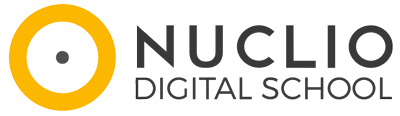


# **Modulo 4. Análisis de datos - Proyecto final**



# **Caso práctico**
***Análisis de mercado para la apertura de centros especializados de Halterofilia***

***Lift & Lead***, es una startup interesada en abrir centros de entrenamiento especializados en halterofilia ya que con el auge del CrossFit, que integra técnicas de halterofilia, los fundadores creen que este puede ser un buen momento para invertir en centros dedicados exclusivamente a este deporte.

La dirección de ***Lift & Lead*** busca validar la hipótesis de que la popularidad del CrossFit está impulsando el interés por la halterofilia en Europa.

Actualmente no cuentan con mucho conocimiento y para empezar a comprender mejor el sector de la halterofilia y a sus atletas, te han asignado la tarea de analizar los resultados de los campeonatos europeos de halterofilia.

El análisis se hará en dos fases:

1. **Fase 1**: Te han proporcionado acceso a la base de datos de 2019 y 2020
  - La información fue obtenida a través de los siguientes enlaces por el anterior Data Analyst que ha dejado la compañía:
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2019
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2020

2. **Fase 2:** Quieren enriquecer el análisis consideranto un periodo más amplio, incluyendo desde 2019 a 2024 pero no disponen de la información. Para obtenerla harás uso de web scraping de los siguientes enlaces:
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2021
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2022
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2023
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2024


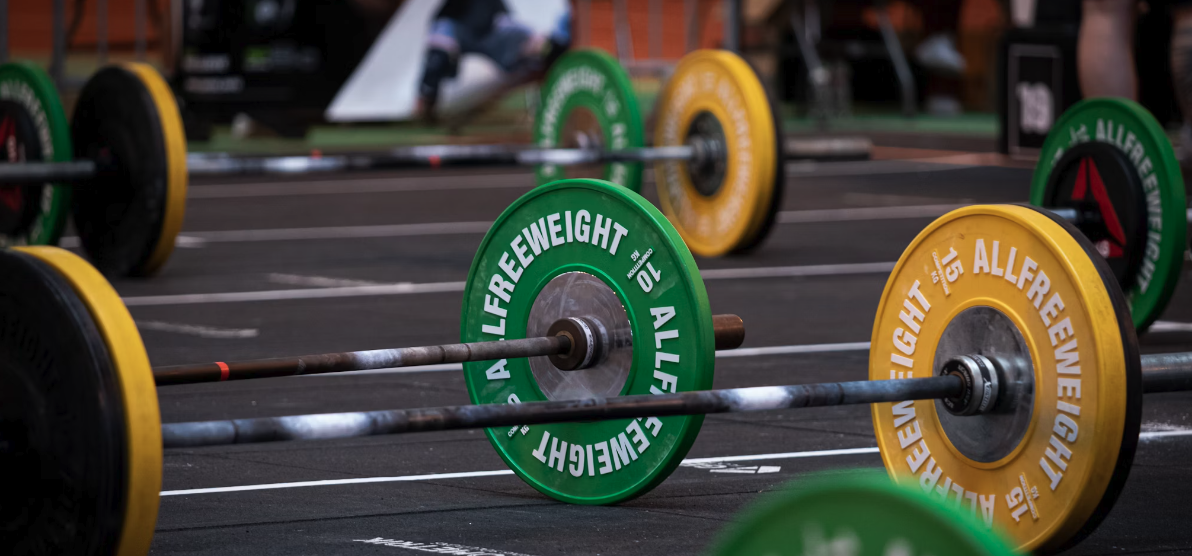

# **Parte 1.** Disponemos de la información

## Paso 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import missingno as msno

import os
import re
from fuzzywuzzy import process

import warnings
warnings.filterwarnings('ignore')

## Paso 2. Cargar datos

In [2]:
def leer_archivo(ruta_completa):
    try:
        _, extension = os.path.splitext(ruta_completa.lower())

        if extension == ".csv":
            df = pd.read_csv(ruta_completa)
        else:
            print("Error: solo se admiten archivos CSV")
            return None

        return df

    except FileNotFoundError:
        print(f"Archivo no encontrado: {ruta_completa}")
        return None

    except Exception as e:
        print(f"Error inesperado: {e}")
        return None

Los datos de 2020 en realidad corresponden a 2021, ya que la edición de 2020 fue cancelada por la pandemia de COVID‑19 y la fuente redirige al campeonato de 2021. Por ello, en el análisis se clasifica como Año = 2021

In [3]:
ruta_2019 = r"C:\Users\kaima\OneDrive\Desktop\vs code\data_analysis_project\data_analysis_project\00_data\00_raw\Campeonato Europeo de Halterofilia de 2019 datos original.csv"
ruta_2021= r"C:\Users\kaima\OneDrive\Desktop\vs code\data_analysis_project\data_analysis_project\00_data\00_raw\Campeonato Europeo de Halterofilia de 2020 datos original.csv"

df_2019 = leer_archivo(ruta_2019)
df_2021 = leer_archivo(ruta_2021)

df_2019["Año"] = 2019
df_2021["Año"] = 2021

df_fase1 = pd.concat([df_2019, df_2021], ignore_index=True)

## Paso 3. Exploración inicial

In [4]:
print("Shape:", df_fase1.shape)
print("Columnas:", df_fase1.columns.tolist())

print("\nInfo:")
df_fase1.info()

print("\nNulos:")
print(df_fase1.isna().sum())

print("\nDuplicados:", df_fase1.duplicated().sum())

print("\nAños:")
print(df_fase1["Año"].value_counts().sort_index())

print("\nGénero:")
print(df_fase1["Genero"].value_counts())

Shape: (40, 6)
Columnas: ['Eventos', 'Oro', 'Plata', 'Bronce', 'Año', 'Genero']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Eventos  40 non-null     object
 1   Oro      40 non-null     object
 2   Plata    40 non-null     object
 3   Bronce   40 non-null     object
 4   Año      40 non-null     int64 
 5   Genero   40 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.0+ KB

Nulos:
Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

Duplicados: 0

Años:
Año
2019    20
2021    20
Name: count, dtype: int64

Género:
Genero
Masculino    20
Femenino     20
Name: count, dtype: int64


## Paso 4. Crear un único dataframe con los datos de 2019 y 2020

In [5]:
df_total = pd.concat([df_2019, df_2021], ignore_index=True)

print("Shape:", df_total.shape)
print(df_total["Año"].value_counts().sort_index())
print(df_total["Genero"].value_counts())

Shape: (40, 6)
Año
2019    20
2021    20
Name: count, dtype: int64
Genero
Masculino    20
Femenino     20
Name: count, dtype: int64


## Paso 5. Transformar los datos

Transforma el DataFrame para tener las siguientes columnas: Eventos, Año, Genero, Medalla (que indica si es Oro, Plata o Bronce) y Atleta (que contiene la información del atleta correspondiente)

Formato inicial:

| Eventos | Oro | Plata | Bronce | Año | Género |
|---------|-----|-------|--------|-----|--------|

**¡Importante!**
El dataframe final debe tener este formato:

| Eventos | Año | Genero | Medalla | Atleta |
|---------|-----|-------|--------|-----|

In [6]:
df_largo = df_total.melt(
    id_vars=["Eventos", "Año", "Genero"],
    value_vars=["Oro", "Plata", "Bronce"],
    var_name="Medalla",
    value_name="Atleta"
)

df_largo["Medalla"] = df_largo["Medalla"].str.capitalize()
df_largo = df_largo[["Eventos", "Año", "Genero", "Medalla", "Atleta"]]

display(df_largo.head(20))
print("Shape largo:", df_largo.shape)

,Eventos,Año,Genero,Medalla,Atleta
0,55 kg (06.04),2019,Masculino,Oro,Mirco Scarantino Italia 116 + 145 = 261[n 1]​
1,61 kg (07.04),2019,Masculino,Oro,Henadz Laptseu Bielorrusia 133 + 153 = 286
2,67 kg (08.04),2019,Masculino,Oro,Bernardin Matam Francia 137 + 175 = 312
3,73 kg (09.04),2019,Masculino,Oro,Bozhidar Andreev Bulgaria 153 + 192 = 345
4,81 kg (10.04),2019,Masculino,Oro,Antonino Pizzolato Italia 155 + 201 = 356
5,89 kg (11.04),2019,Masculino,Oro,Hakob Mkrtchian Armenia 164 + 207 = 371
6,96 kg (12.04),2019,Masculino,Oro,Yauheni Tsijantsou Bielorrusia 178 + 222 = 400
7,102 kg (13.04),2019,Masculino,Oro,Dmytro Chumak Ucrania 175 + 216 = 391
8,109 kg (13.04),2019,Masculino,Oro,Simon Martirosian Armenia 192 + 235 = 427
9,+109 kg (13.04),2019,Masculino,Oro,Lasha Talajadze Georgia 218 + 260 = 478


Shape largo: (120, 5)


## Paso 6. Creación de columnas


- Fecha
- Nombre
- Apellido
- País
- Resultados
- Arrancada
- Dos tiempos
- Total

In [7]:
#Funciones

MULTIWORD_COUNTRIES = {
    "Reino Unido", "República Checa", "Macedonia del Norte", "Bosnia y Herzegovina",
    "San Marino", "Países Bajos", "Nueva Zelanda", "Corea del Sur",
    "Arabia Saudita", "Emiratos Árabes Unidos", "Costa de Marfil",
    "Trinidad y Tobago", "Papúa Nueva Guinea", "Sudáfrica",
    "Hong Kong", "AIN"
}

def limpiar_texto_atleta(s):
    if pd.isna(s):
        return pd.NA
    s = str(s)
    s = re.sub(r"\[[^\]]+\]", "", s)
    s = s.replace("\u200b", "").replace("\xa0", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extraer_fecha(evento, anio):
    if pd.isna(evento) or pd.isna(anio):
        return pd.NaT
    m = re.search(r"\((\d{2})\.(\d{2})\)", str(evento))
    if not m:
        return pd.NaT
    dd, mm = m.group(1), m.group(2)
    return pd.to_datetime(f"{int(anio)}-{mm}-{dd}", errors="coerce")

def parsear_atleta(texto):
    texto = limpiar_texto_atleta(texto)
    if pd.isna(texto):
        return pd.Series([pd.NA, pd.NA, pd.NA, pd.NA, pd.NA, pd.NA, pd.NA])

    m_res = re.search(r"(\d+)\s*\+\s*(\d+)\s*=\s*(\d+)", texto)
    if not m_res:
        return pd.Series([pd.NA, pd.NA, pd.NA, pd.NA, pd.NA, pd.NA, pd.NA])

    a = int(m_res.group(1))
    b = int(m_res.group(2))
    t = int(m_res.group(3))
    resultados = f"{a} + {b} = {t}"

    head = texto[:m_res.start()].strip()
    parts = head.split()
    if len(parts) < 2:
        return pd.Series([pd.NA, pd.NA, pd.NA, resultados, a, b, t])

    cand3 = " ".join(parts[-3:])
    cand2 = " ".join(parts[-2:])
    cand1 = parts[-1]

    if cand3 in MULTIWORD_COUNTRIES:
        pais = cand3
        nombre_ap = parts[:-3]
    elif cand2 in MULTIWORD_COUNTRIES:
        pais = cand2
        nombre_ap = parts[:-2]
    else:
        pais = cand1
        nombre_ap = parts[:-1]

    if len(nombre_ap) == 0:
        return pd.Series([pd.NA, pd.NA, pais, resultados, a, b, t])

    apellido = nombre_ap[-1]
    nombre = " ".join(nombre_ap[:-1]) if len(nombre_ap) > 1 else nombre_ap[0]

    return pd.Series([nombre, apellido, pais, resultados, a, b, t])

In [8]:
df_largo_final = df_largo.copy()

df_largo_final["Fecha"] = df_largo_final.apply(
    lambda x: extraer_fecha(x["Eventos"], x["Año"]),
    axis=1
)
df_largo_final["Fecha"] = pd.to_datetime(df_largo_final["Fecha"], errors="coerce")

cols_parse = ["Nombre", "Apellido", "País", "Resultados", "Arrancada", "Dos tiempos", "Total"]

parsed = df_largo_final["Atleta"].apply(parsear_atleta).apply(pd.Series)
parsed.columns = cols_parse

df_largo_final = pd.concat([df_largo_final.reset_index(drop=True),
                            parsed.reset_index(drop=True)], axis=1)

display(df_largo_final.head(10))
print(df_largo_final[cols_parse].isna().sum())

,Eventos,Año,Genero,Medalla,Atleta,Fecha,Nombre,Apellido,País,Resultados,Arrancada,Dos tiempos,Total
0,55 kg (06.04),2019,Masculino,Oro,Mirco Scarantino Italia 116 + 145 = 261[n 1]​,2019-04-06,Mirco,Scarantino,Italia,116 + 145 = 261,116,145,261
1,61 kg (07.04),2019,Masculino,Oro,Henadz Laptseu Bielorrusia 133 + 153 = 286,2019-04-07,Henadz,Laptseu,Bielorrusia,133 + 153 = 286,133,153,286
2,67 kg (08.04),2019,Masculino,Oro,Bernardin Matam Francia 137 + 175 = 312,2019-04-08,Bernardin,Matam,Francia,137 + 175 = 312,137,175,312
3,73 kg (09.04),2019,Masculino,Oro,Bozhidar Andreev Bulgaria 153 + 192 = 345,2019-04-09,Bozhidar,Andreev,Bulgaria,153 + 192 = 345,153,192,345
4,81 kg (10.04),2019,Masculino,Oro,Antonino Pizzolato Italia 155 + 201 = 356,2019-04-10,Antonino,Pizzolato,Italia,155 + 201 = 356,155,201,356
5,89 kg (11.04),2019,Masculino,Oro,Hakob Mkrtchian Armenia 164 + 207 = 371,2019-04-11,Hakob,Mkrtchian,Armenia,164 + 207 = 371,164,207,371
6,96 kg (12.04),2019,Masculino,Oro,Yauheni Tsijantsou Bielorrusia 178 + 222 = 400,2019-04-12,Yauheni,Tsijantsou,Bielorrusia,178 + 222 = 400,178,222,400
7,102 kg (13.04),2019,Masculino,Oro,Dmytro Chumak Ucrania 175 + 216 = 391,2019-04-13,Dmytro,Chumak,Ucrania,175 + 216 = 391,175,216,391
8,109 kg (13.04),2019,Masculino,Oro,Simon Martirosian Armenia 192 + 235 = 427,2019-04-13,Simon,Martirosian,Armenia,192 + 235 = 427,192,235,427
9,+109 kg (13.04),2019,Masculino,Oro,Lasha Talajadze Georgia 218 + 260 = 478,2019-04-13,Lasha,Talajadze,Georgia,218 + 260 = 478,218,260,478


Nombre         0
Apellido       0
País           0
Resultados     0
Arrancada      0
Dos tiempos    0
Total          0
dtype: int64


## Paso 7. Filtrado de columnas y ordenación

**¡Importante!**
El dataframe final debe contener exclusivamente las siguientes columnas:

| Género    | Categoría | Fecha | Medalla | Nombre | Apellido | País | Arrancada | Dos tiempos | Total |
|-----------|-----------|-------|---------|--------|----------|------|-----------|-------------|-------|

In [9]:
df_final_cols = df_largo_final.copy()

df_final_cols["Categoría"] = df_final_cols["Eventos"].str.extract(r"([+\-]?\d+)\s*kg", expand=False)
df_final_cols["Categoría"] = pd.to_numeric(df_final_cols["Categoría"], errors="coerce")

df_final_cols = df_final_cols.rename(columns={"Genero": "Género"})

df_final_cols = df_final_cols[
["Género", "Categoría", "Fecha", "Medalla", "Nombre", "Apellido", "País", "Arrancada", "Dos tiempos", "Total"]

].copy()

display(df_final_cols.head(10))

,Género,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Masculino,55,2019-04-06,Oro,Mirco,Scarantino,Italia,116,145,261
1,Masculino,61,2019-04-07,Oro,Henadz,Laptseu,Bielorrusia,133,153,286
2,Masculino,67,2019-04-08,Oro,Bernardin,Matam,Francia,137,175,312
3,Masculino,73,2019-04-09,Oro,Bozhidar,Andreev,Bulgaria,153,192,345
4,Masculino,81,2019-04-10,Oro,Antonino,Pizzolato,Italia,155,201,356
5,Masculino,89,2019-04-11,Oro,Hakob,Mkrtchian,Armenia,164,207,371
6,Masculino,96,2019-04-12,Oro,Yauheni,Tsijantsou,Bielorrusia,178,222,400
7,Masculino,102,2019-04-13,Oro,Dmytro,Chumak,Ucrania,175,216,391
8,Masculino,109,2019-04-13,Oro,Simon,Martirosian,Armenia,192,235,427
9,Masculino,109,2019-04-13,Oro,Lasha,Talajadze,Georgia,218,260,478


## Paso 8. Tipo de datos

**¡Importante!**
Los tipos de las columnas deben ser los siguientes:

- **Género**: `object`
- **Categoría**: `category`
- **Fecha**: `datetime64[ns]`
- **Medalla**: `category`
- **Nombre**: `object`
- **Apellido**: `object`
- **País**: `object`
- **Arrancada**: `int64`
- **Dos tiempos**: `int64`
- **Total**: `int64`

In [10]:
df_tipado = df_final_cols.copy()

df_tipado["Género"] = df_tipado["Género"].astype(object)
df_tipado["Nombre"] = df_tipado["Nombre"].astype(object)
df_tipado["Apellido"] = df_tipado["Apellido"].astype(object)
df_tipado["País"] = df_tipado["País"].astype(object)

df_tipado["Fecha"] = pd.to_datetime(df_tipado["Fecha"], errors="coerce")

orden_medallas = ["Oro", "Plata", "Bronce"]
df_tipado["Medalla"] = pd.Categorical(df_tipado["Medalla"], categories=orden_medallas, ordered=True)

df_tipado["Categoría"] = df_tipado["Categoría"].astype("category")

df_tipado["Arrancada"] = pd.to_numeric(df_tipado["Arrancada"], errors="coerce")
df_tipado["Dos tiempos"] = pd.to_numeric(df_tipado["Dos tiempos"], errors="coerce")
df_tipado["Total"] = pd.to_numeric(df_tipado["Total"], errors="coerce")

df_tipado = df_tipado.dropna(subset=["Fecha","Nombre","Apellido","País","Arrancada","Dos tiempos","Total"]).copy()

df_tipado["Arrancada"] = df_tipado["Arrancada"].astype("int64")
df_tipado["Dos tiempos"] = df_tipado["Dos tiempos"].astype("int64")
df_tipado["Total"] = df_tipado["Total"].astype("int64")

df_tipado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Género       120 non-null    object        
 1   Categoría    120 non-null    category      
 2   Fecha        120 non-null    datetime64[ns]
 3   Medalla      120 non-null    category      
 4   Nombre       120 non-null    object        
 5   Apellido     120 non-null    object        
 6   País         120 non-null    object        
 7   Arrancada    120 non-null    int64         
 8   Dos tiempos  120 non-null    int64         
 9   Total        120 non-null    int64         
dtypes: category(2), datetime64[ns](1), int64(3), object(4)
memory usage: 8.7+ KB


## Paso 9. Ordendar
**¡Importante!**
El conjunto de datos debe estar ordenado por las siguientes columnas:
['Genero', 'Categoria', 'Medalla']. La siguiente imagen es un ejemplo:

| Genero   | Categoria | Fecha      | Medalla | Nombre    | Apellido | País      | Arrancada | Dos tiempos | Total |
|----------|-----------|------------|---------|-----------|----------|-----------|-----------|-------------|-------|
| Femenino | 45        | 2020-04-03 | Oro     | Nadezhda  | Nguen    | Bulgaria  | 72        | 83          | 155   |
| Femenino | 45        | 2020-04-03 | Plata   | Ivana     | Petrova  | Bulgaria  | 67        | 85          | 152   |
| Femenino | 45        | 2020-04-03 | Bronce  | Melisa    | Güneş    | Turquía   | 68        | 83          | 151   |
| Femenino | 49        | 2020-04-03 | Oro     | Monica    | Csengeri | Rumania   | 86        | 103         | 189   |
| Femenino | 49        | 2020-04-03 | Plata   | Kristina  | Sobol    | Rusia     | 85        | 96          | 181   |


In [11]:
df_ordenado = df_tipado.sort_values(
    by=["Género", "Categoría", "Medalla"],
    ascending=[True, True, True]
).reset_index(drop=True)

display(df_ordenado.head(10))
df_ordenado.info()

,Género,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Femenino,45,2019-04-06,Oro,Şaziye,Erdoğan,Turquía,75,88,163
1,Femenino,45,2021-04-03,Oro,Nadezhda,Nguen,Bulgaria,72,83,155
2,Femenino,45,2019-04-06,Plata,Ivana,Petrova,Bulgaria,69,89,158
3,Femenino,45,2021-04-03,Plata,Ivana,Petrova,Bulgaria,67,85,152
4,Femenino,45,2019-04-06,Bronce,Yuliya,Asayonak,Bielorrusia,69,81,150
5,Femenino,45,2021-04-03,Bronce,Melisa,Güneş,Turquía,68,83,151
6,Femenino,49,2019-04-06,Oro,Elena,Andrieș,Rumania,87,103,190
7,Femenino,49,2021-04-03,Oro,Monica,Csengeri,Rumania,86,103,189
8,Femenino,49,2019-04-06,Plata,Kristina,Sobol,Rusia,85,95,180
9,Femenino,49,2021-04-03,Plata,Kristina,Sobol,Rusia,85,96,181


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Género       120 non-null    object        
 1   Categoría    120 non-null    category      
 2   Fecha        120 non-null    datetime64[ns]
 3   Medalla      120 non-null    category      
 4   Nombre       120 non-null    object        
 5   Apellido     120 non-null    object        
 6   País         120 non-null    object        
 7   Arrancada    120 non-null    int64         
 8   Dos tiempos  120 non-null    int64         
 9   Total        120 non-null    int64         
dtypes: category(2), datetime64[ns](1), int64(3), object(4)
memory usage: 8.7+ KB


## Paso 10. EDA
Realiza un análisis exploratorio de los datos que te permita ganar conocimiento sobre el conjunto de datos antes de resolver a las preguntas

In [12]:
print("SHAPE:", df_ordenado.shape)
display(df_ordenado.head())
display(df_ordenado.sample(5, random_state=42))

print("\nDTYPES:")
display(df_ordenado.dtypes)

print("\nNULOS:")
display(df_ordenado.isna().sum())

print("\nDUPLICADOS:", df_ordenado.duplicated().sum())

display(df_ordenado.describe(include="all"))

SHAPE: (120, 10)


,Género,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Femenino,45,2019-04-06,Oro,Şaziye,Erdoğan,Turquía,75,88,163
1,Femenino,45,2021-04-03,Oro,Nadezhda,Nguen,Bulgaria,72,83,155
2,Femenino,45,2019-04-06,Plata,Ivana,Petrova,Bulgaria,69,89,158
3,Femenino,45,2021-04-03,Plata,Ivana,Petrova,Bulgaria,67,85,152
4,Femenino,45,2019-04-06,Bronce,Yuliya,Asayonak,Bielorrusia,69,81,150


,Género,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
44,Femenino,81,2019-04-12,Plata,Anna Van,Bellinghen,Bélgica,103,118,221
47,Femenino,81,2021-04-09,Bronce,Liana,Guiurdzhian,Armenia,98,129,227
4,Femenino,45,2019-04-06,Bronce,Yuliya,Asayonak,Bielorrusia,69,81,150
55,Femenino,87,2021-04-11,Plata,Anastasiya,Lysenko,Ucrania,116,136,252
26,Femenino,64,2019-04-09,Plata,Irina,Lepșa,Rumania,102,127,229



DTYPES:


Género                 object
Categoría            category
Fecha          datetime64[ns]
Medalla              category
Nombre                 object
Apellido               object
País                   object
Arrancada               int64
Dos tiempos             int64
Total                   int64
dtype: object


NULOS:


Género         0
Categoría      0
Fecha          0
Medalla        0
Nombre         0
Apellido       0
País           0
Arrancada      0
Dos tiempos    0
Total          0
dtype: int64


DUPLICADOS: 0


,Género,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
count,120,120.0,120,120,120,120,120,120.000000,120.000000,120.000000
unique,2,16.0,NaN,3,85,97,21,NaN,NaN,NaN
top,Femenino,55.0,NaN,Oro,Anastasiya,Asayonak,Rusia,NaN,NaN,NaN
freq,60,12.0,NaN,40,5,3,20,NaN,NaN,NaN
mean,NaN,NaN,2020-04-07 21:36:00,NaN,NaN,NaN,NaN,129.600000,157.391667,286.991667
min,NaN,NaN,2019-04-06 00:00:00,NaN,NaN,NaN,NaN,67.000000,81.000000,150.000000
25%,NaN,NaN,2019-04-10 00:00:00,NaN,NaN,NaN,NaN,99.500000,122.000000,221.750000
50%,NaN,NaN,2020-04-07 12:00:00,NaN,NaN,NaN,NaN,114.500000,145.000000,257.000000
75%,NaN,NaN,2021-04-07 00:00:00,NaN,NaN,NaN,NaN,163.250000,200.000000,366.000000
max,NaN,NaN,2021-04-11 00:00:00,NaN,NaN,NaN,NaN,222.000000,263.000000,485.000000


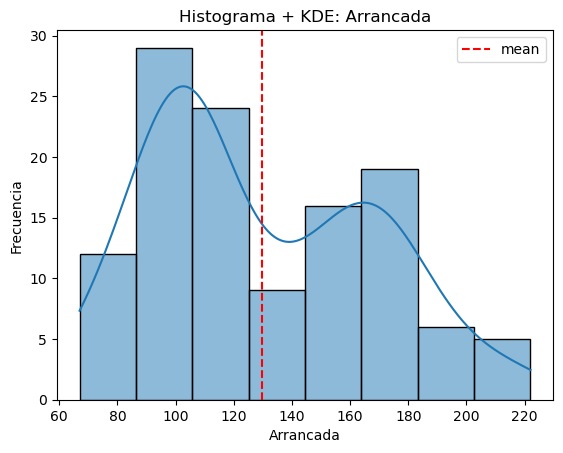

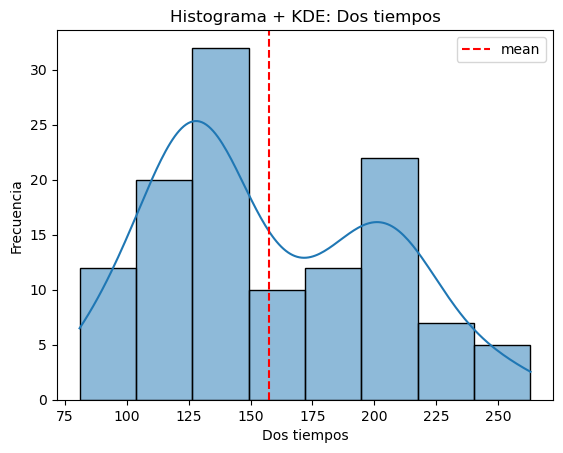

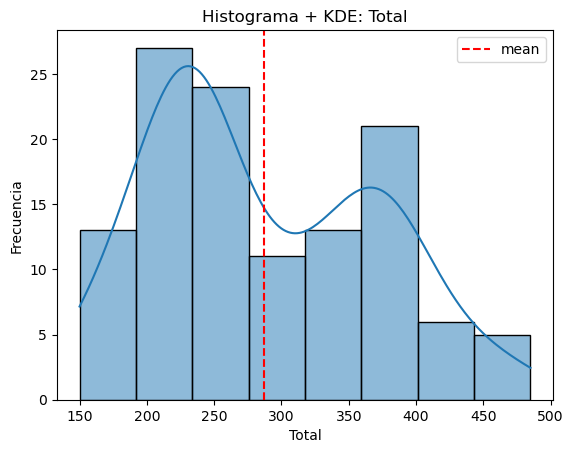

In [13]:
lista_variables_numericas = ["Arrancada", "Dos tiempos", "Total"]

for col in lista_variables_numericas:
    plt.figure()
    sns.histplot(df_ordenado[col], kde=True)
    plt.axvline(df_ordenado[col].mean(), color="red", linestyle="--", label="mean")
    plt.title(f"Histograma + KDE: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()

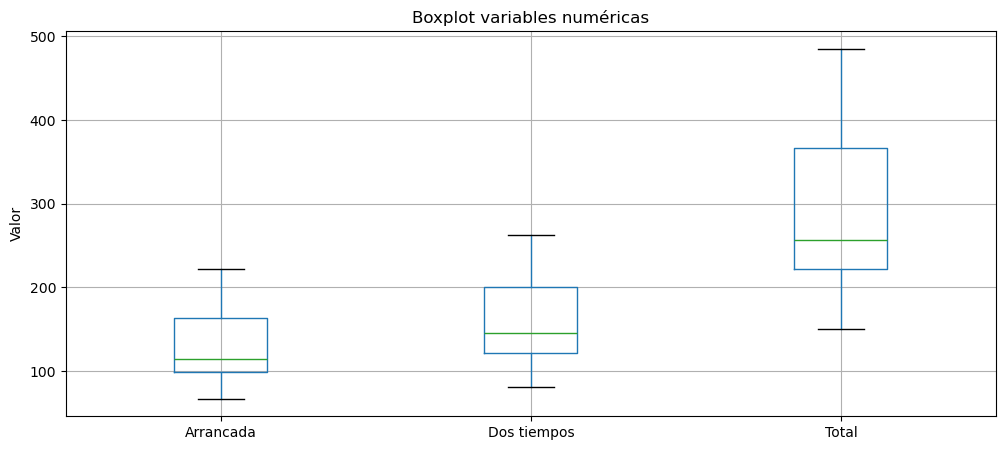

In [14]:
plt.figure(figsize=(12, 5))
df_ordenado[["Arrancada", "Dos tiempos", "Total"]].boxplot()
plt.title("Boxplot variables numéricas")
plt.ylabel("Valor")
plt.show()

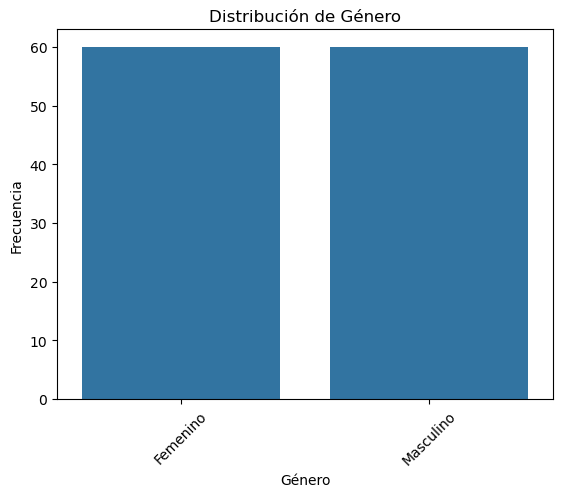

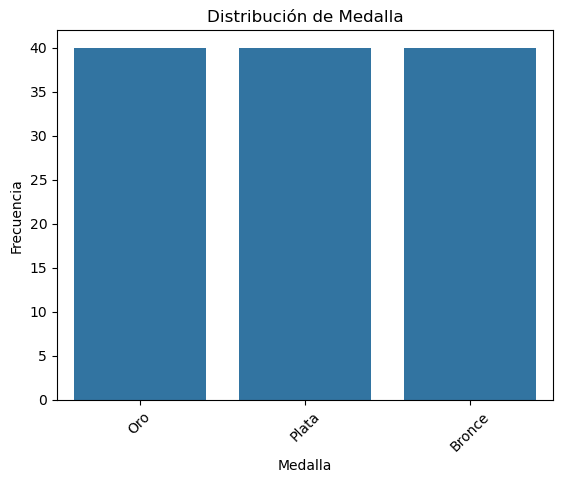

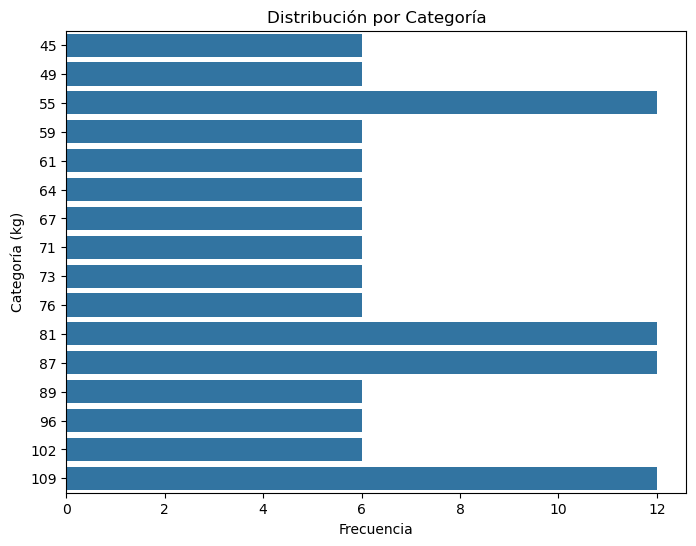

In [15]:
plt.figure()
sns.countplot(data=df_ordenado, x="Género")
plt.title("Distribución de Género")
plt.xlabel("Género")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.countplot(data=df_ordenado, x="Medalla")
plt.title("Distribución de Medalla")
plt.xlabel("Medalla")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(
    data=df_ordenado,
    y="Categoría",
    order=sorted(df_ordenado["Categoría"].unique())
)
plt.title("Distribución por Categoría")
plt.xlabel("Frecuencia")
plt.ylabel("Categoría (kg)")
plt.show()

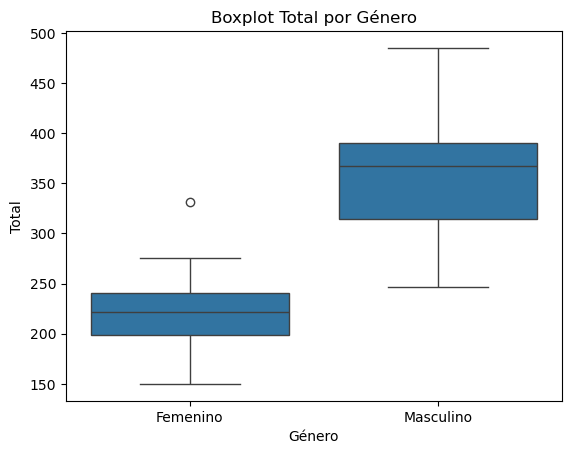

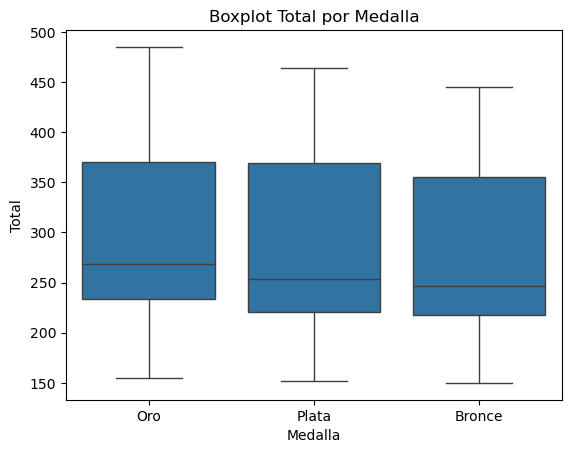

In [16]:
plt.figure()
sns.boxplot(data=df_ordenado, x="Género", y="Total")
plt.title("Boxplot Total por Género")
plt.xlabel("Género")
plt.ylabel("Total")
plt.show()

plt.figure()
sns.boxplot(data=df_ordenado, x="Medalla", y="Total")
plt.title("Boxplot Total por Medalla")
plt.xlabel("Medalla")
plt.ylabel("Total")
plt.show()

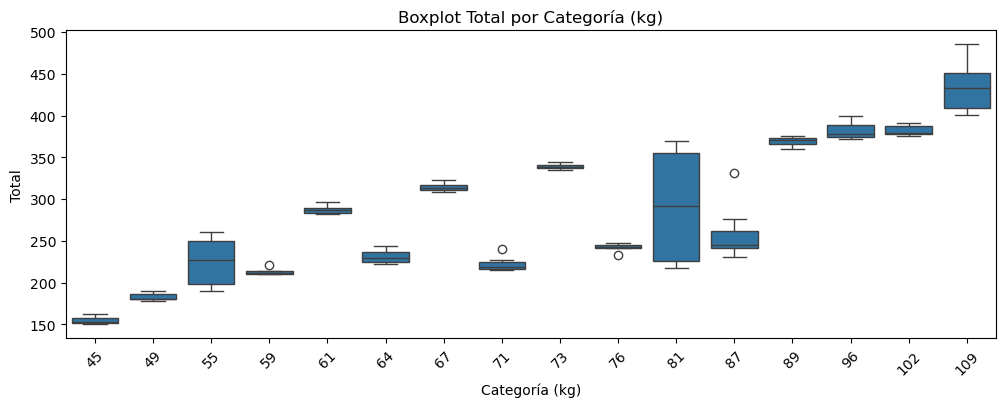

In [17]:
plt.figure(figsize=(12, 4))
sns.boxplot(
    data=df_ordenado,
    x="Categoría",
    y="Total",
    order=sorted(df_ordenado["Categoría"].unique())
)
plt.title("Boxplot Total por Categoría (kg)")
plt.xlabel("Categoría (kg)")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.show()


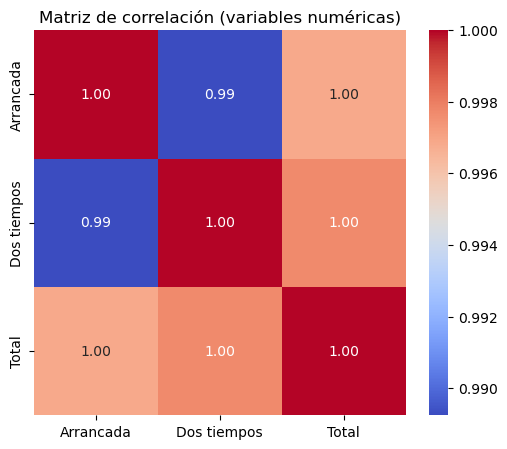

In [18]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    df_ordenado[lista_variables_numericas].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación (variables numéricas)")
plt.show()

## **Preguntas obligatorias a resolver**

### ¿Cuántas medallas de cada tipo (oro, plata y bronce) ha ganado cada país en la competición? (Sin considerar el género)

In [19]:
orden_medallas = ["Oro", "Plata", "Bronce"]

medallas_pais = (
    df_ordenado
    .groupby(["País", "Medalla"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=orden_medallas, fill_value=0)
)

medallas_pais["Total_medallas"] = medallas_pais.sum(axis=1)
medallas_pais = medallas_pais.sort_values("Total_medallas", ascending=False)

display(medallas_pais)

Medalla,Oro,Plata,Bronce,Total_medallas
País,,,,
Rusia,4,9,7,20
Armenia,4,3,7,14
Bulgaria,4,5,1,10
Bielorrusia,3,3,3,9
Georgia,3,4,2,9
Rumania,4,2,3,9
Turquía,3,1,5,9
Ucrania,5,2,1,8
Italia,3,2,1,6


La tabla muestra el número de medallas de oro, plata y bronce obtenidas por cada país en la competición, sin distinguir el género de los atletas. 

El país que ha conseguido más medallas es Rusia, con un total de 20 medallas, entre oro, plata y bronce. Seguida por Armenia con 14 y Bulgaria con 10.

In [20]:
medallas_fase1 = (
    df_ordenado.groupby(["País", "Medalla"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Oro", "Plata", "Bronce"], fill_value=0)
)
medallas_fase1["Total"] = medallas_fase1.sum(axis=1)

plt.figure(figsize=(10, 6))
top5[["Oro", "Plata", "Bronce"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Número de Medallas por País (2019–2021)")
plt.xlabel("País")
plt.ylabel("Número de Medallas")
plt.xticks(rotation=45)
plt.legend(title="Medalla")
plt.tight_layout()
plt.show()

NameError: name 'top5' is not defined

<Figure size 1000x600 with 0 Axes>

### ¿Qué país ha logrado la mayor equidad en términos de éxito entre sus atletas femeninos y masculinos?

In [ ]:
equidad_f1 = (
    df_ordenado
    .groupby(["País", "Género"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Femenino", "Masculino"]:
    if col not in equidad_f1.columns:
        equidad_f1[col] = 0

equidad_f1_validos = equidad_f1[(equidad_f1["Femenino"] > 0) & (equidad_f1["Masculino"] > 0)].copy()

equidad_f1_validos["Diferencia_medallas"] = (equidad_f1_validos["Femenino"] - equidad_f1_validos["Masculino"]).abs()

equidad_f1_validos = equidad_f1_validos.sort_values(
    ["Diferencia_medallas", "Femenino", "Masculino"],
    ascending=[True, False, False]
)

display(equidad_f1_validos)

Género,Femenino,Masculino,Diferencia_medallas
País,,,
Alemania,1,1,0
Azerbaiyán,1,1,0
Moldavia,1,1,0
Francia,2,1,1
Letonia,1,2,1
Ucrania,5,3,2
Italia,2,4,2
Turquía,3,6,3
Bulgaria,3,7,4


La tabla muestra el número de medallas obtenidas por atletas femeninas y masculinos en cada país, así como la diferencia absoluta entre ambos grupos. 

Alemania, Azerbaiyán y Moldavia destacan como los países con mayor equidad, al presentar el mismo número de medallas en ambos géneros.

Es importante señalar que el análisis de equidad se realizó únicamente sobre países con medallas registradas en femenino y masculino, evitando así sesgos derivados de comparar países con participación competitiva limitada a un solo género.

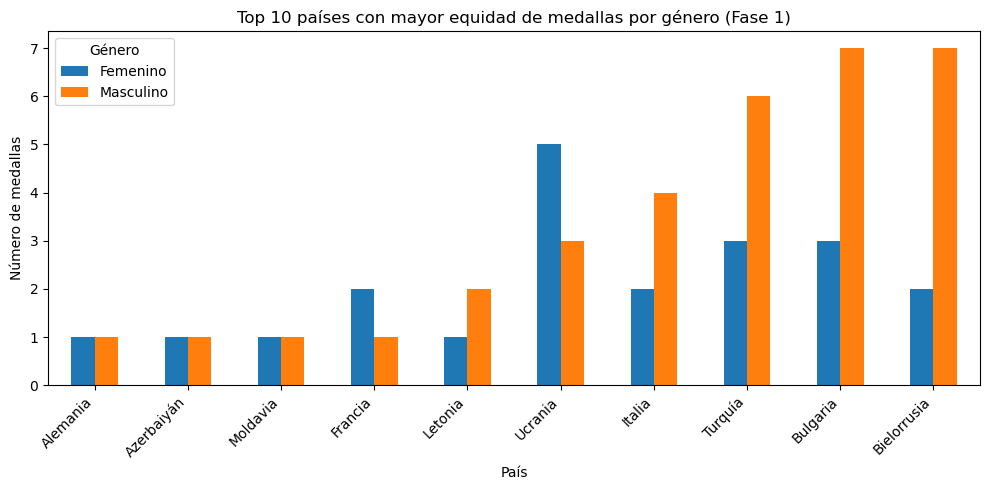

In [ ]:
ax = top10_equidad_f1[["Femenino", "Masculino"]].plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 países con mayor equidad de medallas por género (Fase 1)")
plt.xlabel("País")
plt.ylabel("Número de medallas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### ¿En qué país es menor la diferencia entre el promedio de puntos totales conseguidos por atletas femeninos y masculinos?

In [ ]:
promedio_total_f1 = (
    df_ordenado
    .groupby(["País", "Género"])["Total"]
    .mean()
    .unstack()
)

promedio_total_f1 = promedio_total_f1.dropna(subset=["Femenino", "Masculino"]).copy()

promedio_total_f1["Diferencia_promedio_total"] = (promedio_total_f1["Femenino"] - promedio_total_f1["Masculino"]).abs()

promedio_total_f1 = promedio_total_f1.sort_values("Diferencia_promedio_total", ascending=True)

promedio_total_f1_rounded = promedio_total_f1.round(2)

display(promedio_total_f1_rounded)

dif_min_prom_f1 = promedio_total_f1_rounded["Diferencia_promedio_total"].min()
paises_menor_dif_prom_f1 = promedio_total_f1_rounded[
    promedio_total_f1_rounded["Diferencia_promedio_total"] == dif_min_prom_f1
]

Género,Femenino,Masculino,Diferencia_promedio_total
País,,,
Rumania,213.00,248.00,35.00
Alemania,222.00,311.00,89.00
Francia,220.50,312.00,91.50
Moldavia,245.00,339.00,94.00
Ucrania,242.40,348.33,105.93
Turquía,185.67,293.83,108.17
Italia,198.50,326.25,127.75
Letonia,221.00,350.50,129.50
Bulgaria,155.00,320.71,165.71


Rumanía es el país que presenta la menor diferencia en el promedio de puntos totales entre atletas femeninos y masculinos, con una variación aproximada de 35 puntos entre ambos géneros.

Este resultado se obtuvo calculando el promedio de la variable *Total* por país y género y, posteriormente, evaluando la diferencia absoluta entre ambos valores.

Para asegurar la validez del análisis, la comparación se realizó únicamente entre países con resultados competitivos registrados en ambos géneros.

Este criterio evita distorsiones derivadas de países sin presencia efectiva en uno de los grupos y garantiza que las conclusiones reflejen diferencias reales en el rendimiento deportivo.

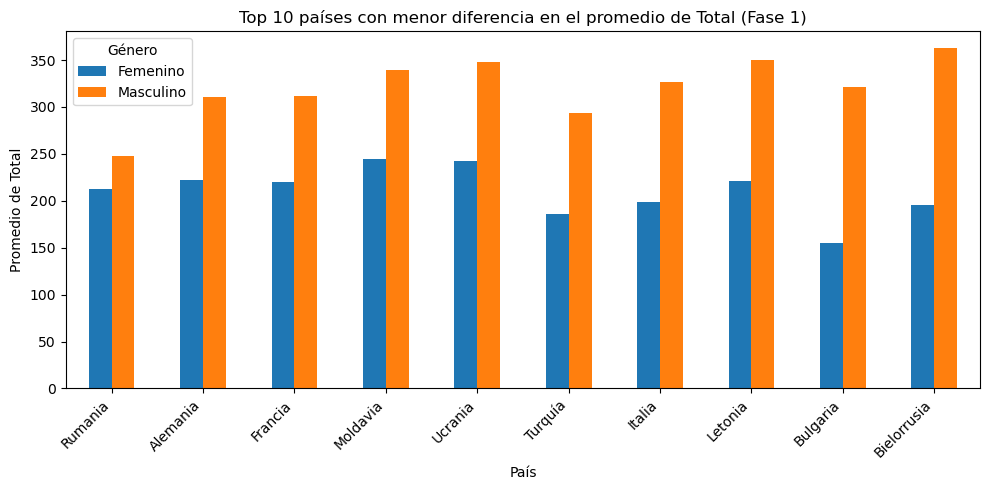

In [ ]:
ax = top10_prom_f1[["Femenino", "Masculino"]].plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 países con menor diferencia en el promedio de Total (Fase 1)")
plt.xlabel("País")
plt.ylabel("Promedio de Total")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# **Fase 2.** Web scraping

## Paso 1. Importar librerías

In [ ]:
import requests
from bs4 import BeautifulSoup

import pandas as pd
import numpy as np

import re
import time

from typing import List

## Paso 2. Cargar datos

In [ ]:
def leer_archivo(ruta_completa):
    try:
        _, extension = os.path.splitext(ruta_completa.lower())

        if extension == ".csv":
            df = pd.read_csv(ruta_completa)
        else:
            print("Error: solo se admiten archivos CSV")
            return None

        return df

    except FileNotFoundError:
        print(f"Archivo no encontrado: {ruta_completa}")
        return None

    except Exception as e:
        print(f"Error inesperado: {e}")
        return None

In [ ]:
ruta_2022 = r"C:\Users\kaima\OneDrive\Desktop\vs code\data_analysis_project\data_analysis_project\00_data\00_raw\Campeonato Europeo de Halterofilia de 2022 datos original.csv"
ruta_2023 = r"C:\Users\kaima\OneDrive\Desktop\vs code\data_analysis_project\data_analysis_project\00_data\00_raw\Campeonato Europeo de Halterofilia de 2023 datos original.csv"
ruta_2024 = r"C:\Users\kaima\OneDrive\Desktop\vs code\data_analysis_project\data_analysis_project\00_data\00_raw\Campeonato Europeo de Halterofilia de 2024 datos original.csv"

df_2022 = leer_archivo(ruta_2022)
df_2023 = leer_archivo(ruta_2023)
df_2024 = leer_archivo(ruta_2024)

df_2022["Año"] = 2022
df_2023["Año"] = 2023
df_2024["Año"] = 2024

df_fase2 = pd.concat(
    [df_2019, df_2021, df_2022, df_2023, df_2024],
    ignore_index=True
)

In [ ]:
print("\nShape:")
print(df_fase2.shape)

print("\nColumnas:")
print(df_fase2.columns.tolist())

print("\nInformación general:")
df_fase2.info()

print("\nValores nulos por columna:")
print(df_fase2.isna().sum())

print("\nDistribución por año:")
print(df_fase2["Año"].value_counts().sort_index())

print("\nDistribución por género:")
print(df_fase2["Genero"].value_counts())

print("\nEjemplo de filas:")
display(df_fase2.sample(5, random_state=42))



Shape:
(100, 6)

Columnas:
['Eventos', 'Oro', 'Plata', 'Bronce', 'Año', 'Genero']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Eventos  100 non-null    object
 1   Oro      100 non-null    object
 2   Plata    100 non-null    object
 3   Bronce   100 non-null    object
 4   Año      100 non-null    int64 
 5   Genero   100 non-null    object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB

Valores nulos por columna:
Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

Distribución por año:
Año
2019    20
2021    20
2022    20
2023    20
2024    20
Name: count, dtype: int64

Distribución por género:
Genero
Masculino    50
Femenino     50
Name: count, dtype: int64

Ejemplo de filas:


,Eventos,Oro,Plata,Bronce,Año,Genero
83,73 kg (15.02),Bozhidar Andreev Bulgaria 155 + 193 = 348,Muhammed Özbek Turquía 150 + 186 = 336,Ritvars Suharevs Letonia 154 + 177 = 331,2024,Masculino
53,59 kg (30.05),Dora Tchakounté Francia 96 + 117 = 213,Lucrezia Magistris Italia 98 + 114 = 212,Ine Andersson Noruega 90 + 118 = 208,2022,Femenino
70,45 kg (15.04),Cansu Bektaş Turquía 72 + 90 = 162[n 1]​,Adriana Pană Rumania 70 + 83 = 153[n 1]​,Marta García Rincón España 68 + 85 = 153[n 1]​,2023,Femenino
45,89 kg (02.06),Antonino Pizzolato Italia 175 + 217 = 392,Karlos Nasar Bulgaria 171 + 211 = 382,Revaz Davitadze Georgia 171 + 198 = 369,2022,Masculino
44,81 kg (01.06),Rafik Harutiunian Armenia 160 + 194 = 354,Andrés Mata Pérez España 160 + 186 = 346,Bozhidar Andreev Bulgaria 153 + 190 = 343,2022,Masculino


## Paso 3. Exploración inicial

In [ ]:
print("Shape:", df_fase2.shape)
print("Columnas:", df_fase2.columns.tolist())

print("\nInfo:")
df_fase2.info()

print("\nNulos:")
print(df_fase2.isna().sum())

print("\nDuplicados:", df_fase2.duplicated().sum())

print("\nAños:")
print(df_fase2["Año"].value_counts().sort_index())

print("\nGénero:")
print(df_fase2["Genero"].value_counts())

Shape: (100, 6)
Columnas: ['Eventos', 'Oro', 'Plata', 'Bronce', 'Año', 'Genero']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Eventos  100 non-null    object
 1   Oro      100 non-null    object
 2   Plata    100 non-null    object
 3   Bronce   100 non-null    object
 4   Año      100 non-null    int64 
 5   Genero   100 non-null    object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB

Nulos:
Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

Duplicados: 0

Años:
Año
2019    20
2021    20
2022    20
2023    20
2024    20
Name: count, dtype: int64

Género:
Genero
Masculino    50
Femenino     50
Name: count, dtype: int64


Se observa que los datos de 2022–2024 mantienen la misma estructura que en la Fase 1. Se verifican tipos de datos, valores nulos y una muestra de registros para asegurar que todo sea coherente antes de iniciar la transformación y el análisis.

## Paso 4. Crear un único dataframe con los datos de 2019, 2020, 2021, 2022, 2023 y 2024

In [ ]:
df_total_2 = pd.concat([df_2019, df_2021, df_2022, df_2023, df_2024], ignore_index=True)

print("Shape df_total_2:", df_total_2.shape)
print(df_total_2["Año"].value_counts().sort_index())
print(df_total_2["Genero"].value_counts())

Shape df_total_2: (100, 6)
Año
2019    20
2021    20
2022    20
2023    20
2024    20
Name: count, dtype: int64
Genero
Masculino    50
Femenino     50
Name: count, dtype: int64


## Paso 5. Transformar los datos

Transforma el DataFrame para tener las siguientes columnas: Eventos, Año, Genero, Medalla (que indica si es Oro, Plata o Bronce) y Atleta (que contiene la información del atleta correspondiente)

Formato inicial:

| Eventos | Oro | Plata | Bronce | Año | Género |
|---------|-----|-------|--------|-----|--------|

**¡Importante!**
El dataframe final debe tener este formato:

| Eventos | Año | Genero | Medalla | Atleta |
|---------|-----|-------|--------|-----|

In [ ]:
df_largo_2 = df_total_2.melt(
    id_vars=["Eventos", "Año", "Genero"],
    value_vars=["Oro", "Plata", "Bronce"],
    var_name="Medalla",
    value_name="Atleta"
)

df_largo_2["Medalla"] = df_largo_2["Medalla"].str.capitalize()

display(df_largo_2.head())
print(df_largo_2["Año"].value_counts().sort_index())

,Eventos,Año,Genero,Medalla,Atleta
0,55 kg (06.04),2019,Masculino,Oro,Mirco Scarantino Italia 116 + 145 = 261[n 1]​
1,61 kg (07.04),2019,Masculino,Oro,Henadz Laptseu Bielorrusia 133 + 153 = 286
2,67 kg (08.04),2019,Masculino,Oro,Bernardin Matam Francia 137 + 175 = 312
3,73 kg (09.04),2019,Masculino,Oro,Bozhidar Andreev Bulgaria 153 + 192 = 345
4,81 kg (10.04),2019,Masculino,Oro,Antonino Pizzolato Italia 155 + 201 = 356


Año
2019    60
2021    60
2022    60
2023    60
2024    60
Name: count, dtype: int64


## Paso 6. Creación de columnas


- Fecha
- Nombre
- Apellido
- País
- Resultados
- Arrancada
- Dos tiempos
- Total

In [ ]:
df_largo_final_2 = df_largo_2.copy()

df_largo_final_2["Fecha"] = df_largo_final_2.apply(
    lambda x: extraer_fecha(x["Eventos"], x["Año"]),
    axis=1
)
df_largo_final_2["Fecha"] = pd.to_datetime(df_largo_final_2["Fecha"], errors="coerce")

cols_parse = ["Nombre", "Apellido", "País", "Resultados", "Arrancada", "Dos tiempos", "Total"]

cols_existentes = [c for c in cols_parse if c in df_largo_final_2.columns]
if cols_existentes:
    df_largo_final_2 = df_largo_final_2.drop(columns=cols_existentes)

parsed_2 = df_largo_final_2["Atleta"].apply(parsear_atleta).apply(pd.Series)
parsed_2.columns = cols_parse

df_largo_final_2 = pd.concat(
    [df_largo_final_2.reset_index(drop=True), parsed_2.reset_index(drop=True)],
    axis=1
)

print("Shape:", df_largo_final_2.shape)
print("\nAños:")
print(df_largo_final_2["Año"].value_counts().sort_index())

display(df_largo_final_2.head(10))

Shape: (300, 13)

Años:
Año
2019    60
2021    60
2022    60
2023    60
2024    60
Name: count, dtype: int64


,Eventos,Año,Genero,Medalla,Atleta,Fecha,Nombre,Apellido,País,Resultados,Arrancada,Dos tiempos,Total
0,55 kg (06.04),2019,Masculino,Oro,Mirco Scarantino Italia 116 + 145 = 261[n 1]​,2019-04-06,Mirco,Scarantino,Italia,116 + 145 = 261,116,145,261
1,61 kg (07.04),2019,Masculino,Oro,Henadz Laptseu Bielorrusia 133 + 153 = 286,2019-04-07,Henadz,Laptseu,Bielorrusia,133 + 153 = 286,133,153,286
2,67 kg (08.04),2019,Masculino,Oro,Bernardin Matam Francia 137 + 175 = 312,2019-04-08,Bernardin,Matam,Francia,137 + 175 = 312,137,175,312
3,73 kg (09.04),2019,Masculino,Oro,Bozhidar Andreev Bulgaria 153 + 192 = 345,2019-04-09,Bozhidar,Andreev,Bulgaria,153 + 192 = 345,153,192,345
4,81 kg (10.04),2019,Masculino,Oro,Antonino Pizzolato Italia 155 + 201 = 356,2019-04-10,Antonino,Pizzolato,Italia,155 + 201 = 356,155,201,356
5,89 kg (11.04),2019,Masculino,Oro,Hakob Mkrtchian Armenia 164 + 207 = 371,2019-04-11,Hakob,Mkrtchian,Armenia,164 + 207 = 371,164,207,371
6,96 kg (12.04),2019,Masculino,Oro,Yauheni Tsijantsou Bielorrusia 178 + 222 = 400,2019-04-12,Yauheni,Tsijantsou,Bielorrusia,178 + 222 = 400,178,222,400
7,102 kg (13.04),2019,Masculino,Oro,Dmytro Chumak Ucrania 175 + 216 = 391,2019-04-13,Dmytro,Chumak,Ucrania,175 + 216 = 391,175,216,391
8,109 kg (13.04),2019,Masculino,Oro,Simon Martirosian Armenia 192 + 235 = 427,2019-04-13,Simon,Martirosian,Armenia,192 + 235 = 427,192,235,427
9,+109 kg (13.04),2019,Masculino,Oro,Lasha Talajadze Georgia 218 + 260 = 478,2019-04-13,Lasha,Talajadze,Georgia,218 + 260 = 478,218,260,478


## Paso 7. Filtrado de columnas y ordenación

**¡Importante!**
El dataframe final debe contener exclusivamente las siguientes columnas:

| Género    | Categoría | Fecha | Medalla | Nombre | Apellido | País | Arrancada | Dos tiempos | Total |
|-----------|-----------|-------|---------|--------|----------|------|-----------|-------------|-------|

In [ ]:
df_final_cols_2 = df_largo_final_2.copy()

df_final_cols_2["Categoría"] = (
    df_final_cols_2["Eventos"]
    .astype(str)
    .str.extract(r"(\d+)\s*kg", expand=False)
)

df_final_cols_2["Categoría"] = pd.to_numeric(df_final_cols_2["Categoría"], errors="coerce")

df_final_cols_2 = df_final_cols_2[
    ["Genero", "Categoría", "Fecha", "Medalla", "Nombre", "Apellido", "País", "Arrancada", "Dos tiempos", "Total"]
].copy()

df_final_cols_2 = df_final_cols_2.rename(columns={"Genero": "Género"})

print("Shape df_final_cols_2:", df_final_cols_2.shape)
display(df_final_cols_2.head(10))


Shape df_final_cols_2: (300, 10)


,Género,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Masculino,55,2019-04-06,Oro,Mirco,Scarantino,Italia,116,145,261
1,Masculino,61,2019-04-07,Oro,Henadz,Laptseu,Bielorrusia,133,153,286
2,Masculino,67,2019-04-08,Oro,Bernardin,Matam,Francia,137,175,312
3,Masculino,73,2019-04-09,Oro,Bozhidar,Andreev,Bulgaria,153,192,345
4,Masculino,81,2019-04-10,Oro,Antonino,Pizzolato,Italia,155,201,356
5,Masculino,89,2019-04-11,Oro,Hakob,Mkrtchian,Armenia,164,207,371
6,Masculino,96,2019-04-12,Oro,Yauheni,Tsijantsou,Bielorrusia,178,222,400
7,Masculino,102,2019-04-13,Oro,Dmytro,Chumak,Ucrania,175,216,391
8,Masculino,109,2019-04-13,Oro,Simon,Martirosian,Armenia,192,235,427
9,Masculino,109,2019-04-13,Oro,Lasha,Talajadze,Georgia,218,260,478


## Paso 8. Tipo de datos

**¡Importante!**
Los tipos de las columnas deben ser los siguientes:

- **Género**: `object`
- **Categoría**: `category`
- **Fecha**: `datetime64[ns]`
- **Medalla**: `category`
- **Nombre**: `object`
- **Apellido**: `object`
- **País**: `object`
- **Arrancada**: `int64`
- **Dos tiempos**: `int64`
- **Total**: `int64`

In [ ]:
df_tipado_2 = df_final_cols_2.copy()

df_tipado_2["Género"] = df_tipado_2["Género"].astype(object)
df_tipado_2["Categoría"] = df_tipado_2["Categoría"].astype("category")

orden_medallas = ["Oro", "Plata", "Bronce"]
df_tipado_2["Medalla"] = pd.Categorical(df_tipado_2["Medalla"], categories=orden_medallas, ordered=True)

df_tipado_2["Nombre"] = df_tipado_2["Nombre"].astype(object)
df_tipado_2["Apellido"] = df_tipado_2["Apellido"].astype(object)
df_tipado_2["País"] = df_tipado_2["País"].astype(object)

for c in ["Arrancada", "Dos tiempos", "Total"]:
    df_tipado_2[c] = pd.to_numeric(df_tipado_2[c], errors="coerce")

df_tipado_2 = df_tipado_2.dropna(subset=["Arrancada", "Dos tiempos", "Total"]).copy()

df_tipado_2["Arrancada"] = df_tipado_2["Arrancada"].astype("int64")
df_tipado_2["Dos tiempos"] = df_tipado_2["Dos tiempos"].astype("int64")
df_tipado_2["Total"] = df_tipado_2["Total"].astype("int64")

df_tipado_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Género       300 non-null    object        
 1   Categoría    300 non-null    category      
 2   Fecha        300 non-null    datetime64[ns]
 3   Medalla      300 non-null    category      
 4   Nombre       300 non-null    object        
 5   Apellido     300 non-null    object        
 6   País         300 non-null    object        
 7   Arrancada    300 non-null    int64         
 8   Dos tiempos  300 non-null    int64         
 9   Total        300 non-null    int64         
dtypes: category(2), datetime64[ns](1), int64(3), object(4)
memory usage: 20.3+ KB


## Paso 9. Ordendar
**¡Importante!**
El conjunto de datos debe estar ordenado por las siguientes columnas:
['Genero', 'Categoria', 'Medalla']. La siguiente imagen es un ejemplo:

| Genero   | Categoria | Fecha      | Medalla | Nombre    | Apellido | País      | Arrancada | Dos tiempos | Total |
|----------|-----------|------------|---------|-----------|----------|-----------|-----------|-------------|-------|
| Femenino | 45        | 2020-04-03 | Oro     | Nadezhda  | Nguen    | Bulgaria  | 72        | 83          | 155   |
| Femenino | 45        | 2020-04-03 | Plata   | Ivana     | Petrova  | Bulgaria  | 67        | 85          | 152   |
| Femenino | 45        | 2020-04-03 | Bronce  | Melisa    | Güneş    | Turquía   | 68        | 83          | 151   |
| Femenino | 49        | 2020-04-03 | Oro     | Monica    | Csengeri | Rumania   | 86        | 103         | 189   |
| Femenino | 49        | 2020-04-03 | Plata   | Kristina  | Sobol    | Rusia     | 85        | 96          | 181   |


In [ ]:
orden_medallas = ["Oro", "Plata", "Bronce"]
df_tipado_2["Medalla"] = pd.Categorical(
    df_tipado_2["Medalla"],
    categories=orden_medallas,
    ordered=True
)

df_ordenado_2 = df_tipado_2.sort_values(
    by=["Género", "Categoría", "Medalla", "Fecha"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("Shape df_ordenado_2:", df_ordenado_2.shape)
display(df_ordenado_2.head(10))

Shape df_ordenado_2: (300, 10)


,Género,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Femenino,45,2019-04-06,Oro,Şaziye,Erdoğan,Turquía,75,88,163
1,Femenino,45,2021-04-03,Oro,Nadezhda,Nguen,Bulgaria,72,83,155
2,Femenino,45,2022-05-28,Oro,Şaziye,Erdoğan,Turquía,73,90,163
3,Femenino,45,2023-04-15,Oro,Cansu,Bektaş,Turquía,72,90,162
4,Femenino,45,2024-02-12,Oro,Cansu,Bektaş,Turquía,75,88,163
5,Femenino,45,2019-04-06,Plata,Ivana,Petrova,Bulgaria,69,89,158
6,Femenino,45,2021-04-03,Plata,Ivana,Petrova,Bulgaria,67,85,152
7,Femenino,45,2022-05-28,Plata,Cansu,Bektaş,Turquía,68,85,153
8,Femenino,45,2023-04-15,Plata,Adriana,Pană,Rumania,70,83,153
9,Femenino,45,2024-02-12,Plata,Gamze,Altun,Turquía,65,92,157


## Paso 10. EDA
Realiza un análisis exploratorio de los datos que te permita ganar conocimiento sobre el conjunto de datos antes de resolver a las preguntas

In [ ]:
print("SHAPE:", df_ordenado_2.shape)
display(df_ordenado_2.head())
display(df_ordenado_2.sample(5, random_state=42))

print("\nDTYPES:")
display(df_ordenado_2.dtypes)

print("\nNULOS:")
display(df_ordenado_2.isna().sum())

print("\nDUPLICADOS:", df_ordenado_2.duplicated().sum())

display(df_ordenado_2.describe(include="all"))

SHAPE: (300, 10)


,Género,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Femenino,45,2019-04-06,Oro,Şaziye,Erdoğan,Turquía,75,88,163
1,Femenino,45,2021-04-03,Oro,Nadezhda,Nguen,Bulgaria,72,83,155
2,Femenino,45,2022-05-28,Oro,Şaziye,Erdoğan,Turquía,73,90,163
3,Femenino,45,2023-04-15,Oro,Cansu,Bektaş,Turquía,72,90,162
4,Femenino,45,2024-02-12,Oro,Cansu,Bektaş,Turquía,75,88,163


,Género,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
203,Masculino,73,2023-04-18,Plata,David Sánchez,López,España,150,185,335
266,Masculino,102,2021-04-10,Bronce,Dadaş,Dadaşbəyli,Azerbaiyán,177,202,379
152,Masculino,55,2022-05-29,Oro,Anguel,Rusev,Bulgaria,113,144,257
9,Femenino,45,2024-02-12,Plata,Gamze,Altun,Turquía,65,92,157
233,Masculino,89,2023-04-20,Plata,Andranik,Karapetian,Armenia,178,196,374



DTYPES:


Género                 object
Categoría            category
Fecha          datetime64[ns]
Medalla              category
Nombre                 object
Apellido               object
País                   object
Arrancada               int64
Dos tiempos             int64
Total                   int64
dtype: object


NULOS:


Género         0
Categoría      0
Fecha          0
Medalla        0
Nombre         0
Apellido       0
País           0
Arrancada      0
Dos tiempos    0
Total          0
dtype: int64


DUPLICADOS: 0


,Género,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
count,300,300.0,300,300,300,300,300,300.000000,300.000000,300.000000
unique,2,16.0,NaN,3,152,170,27,NaN,NaN,NaN
top,Femenino,55.0,NaN,Oro,Anastasiya,Campbell,Armenia,NaN,NaN,NaN
freq,150,30.0,NaN,100,11,5,44,NaN,NaN,NaN
mean,NaN,NaN,2022-01-27 18:14:24,NaN,NaN,NaN,NaN,128.253333,155.543333,284.136667
min,NaN,NaN,2019-04-06 00:00:00,NaN,NaN,NaN,NaN,65.000000,11.000000,150.000000
25%,NaN,NaN,2021-04-04 18:00:00,NaN,NaN,NaN,NaN,99.000000,120.000000,221.000000
50%,NaN,NaN,2022-06-01 00:00:00,NaN,NaN,NaN,NaN,114.000000,141.000000,254.500000
75%,NaN,NaN,2023-04-21 06:00:00,NaN,NaN,NaN,NaN,162.250000,196.000000,360.750000
max,NaN,NaN,2024-02-20 00:00:00,NaN,NaN,NaN,NaN,222.000000,263.000000,485.000000


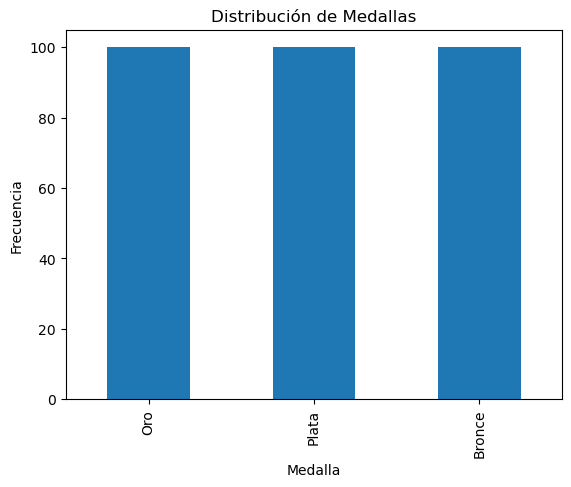

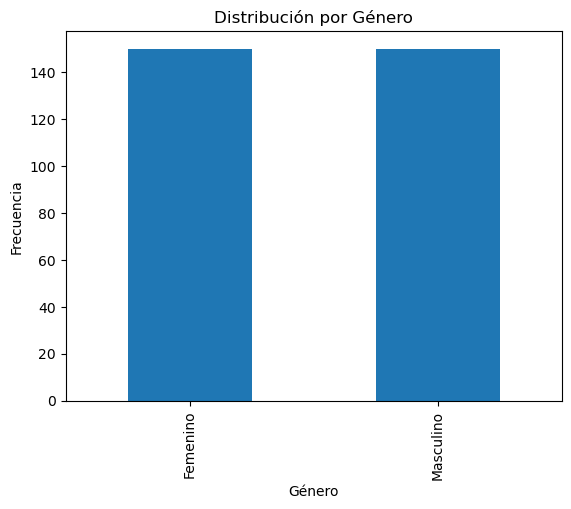

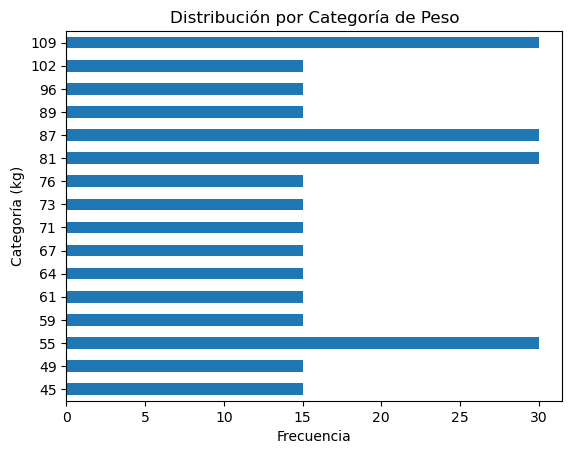

In [ ]:
df_ordenado_2["Medalla"].value_counts().plot(kind="bar")
plt.title("Distribución de Medallas")
plt.xlabel("Medalla")
plt.ylabel("Frecuencia")
plt.show()

df_ordenado_2["Género"].value_counts().plot(kind="bar")
plt.title("Distribución por Género")
plt.xlabel("Género")
plt.ylabel("Frecuencia")
plt.show()

df_ordenado_2["Categoría"].value_counts().sort_index().plot(kind="barh")
plt.title("Distribución por Categoría de Peso")
plt.xlabel("Frecuencia")
plt.ylabel("Categoría (kg)")
plt.show()

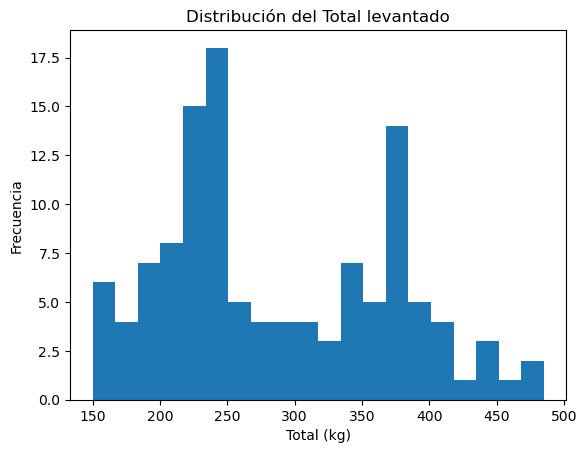

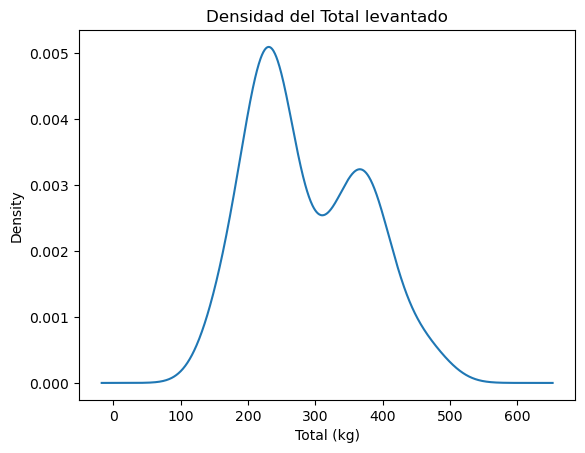

In [ ]:
df_ordenado_2["Total"].plot(kind="hist", bins=20)
plt.title("Distribución del Total levantado")
plt.xlabel("Total (kg)")
plt.ylabel("Frecuencia")
plt.show()

df_ordenado_2["Total"].plot(kind="density")
plt.title("Densidad del Total levantado")
plt.xlabel("Total (kg)")
plt.show()

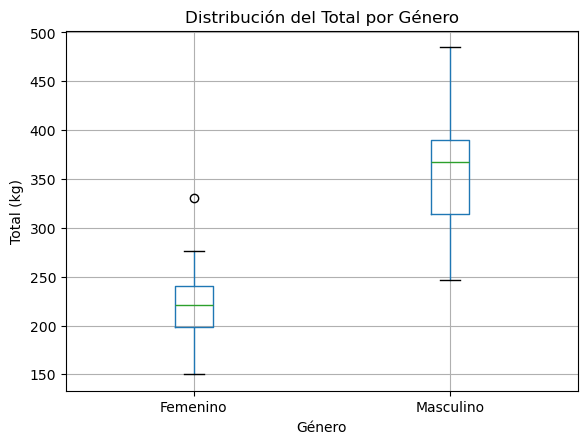

In [ ]:
df_ordenado_2.boxplot(column="Total", by="Género")
plt.title("Distribución del Total por Género")
plt.suptitle("")
plt.xlabel("Género")
plt.ylabel("Total (kg)")
plt.show()

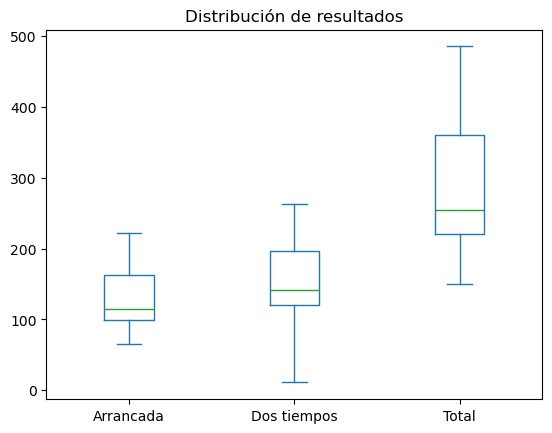

In [ ]:
df_ordenado_2[["Arrancada", "Dos tiempos", "Total"]].plot(
    kind="box",
    title="Distribución de resultados",
)
plt.show()

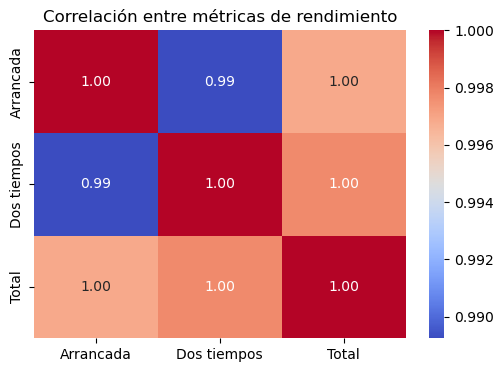

In [ ]:
corr = df_ordenado_2[["Arrancada", "Dos tiempos", "Total"]].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre métricas de rendimiento")
plt.show()

El análisis permite observar cómo se distribuye el rendimiento total entre la fase de arrancada y la de dos tiempos, identificando cuál contribuye más al resultado final y cómo varía entre países/géneros.

## **Preguntas obligatorias a resolver**

### ¿Cuántas medallas de cada tipo (oro, plata y bronce) ha ganado cada país en la competición? (Sin considerar el género)

In [ ]:
orden_medallas = ["Oro", "Plata", "Bronce"]

medallas_pais = (
    df_ordenado_2
    .groupby(["País", "Medalla"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=orden_medallas, fill_value=0)
)

medallas_pais["Total_medallas"] = medallas_pais.sum(axis=1)
medallas_pais = medallas_pais.sort_values("Total_medallas", ascending=False)

display(medallas_pais)

Medalla,Oro,Plata,Bronce,Total_medallas
País,,,,
Armenia,14,13,17,44
Bulgaria,15,8,5,28
Turquía,8,9,11,28
Ucrania,11,11,5,27
Georgia,6,13,5,24
Rusia,4,9,7,20
Italia,8,8,3,19
Rumania,9,3,4,16
Reino Unido,5,2,4,11


La tabla muestra el total de medallas obtenidas por cada país en el Campeonato (2019–2024), sin distinguir el género de los atletas.  
Armenia lidera el medallero con un total de 44 medallas, seguida por Bulgaria y Turquía, ambas con 28 medallas.

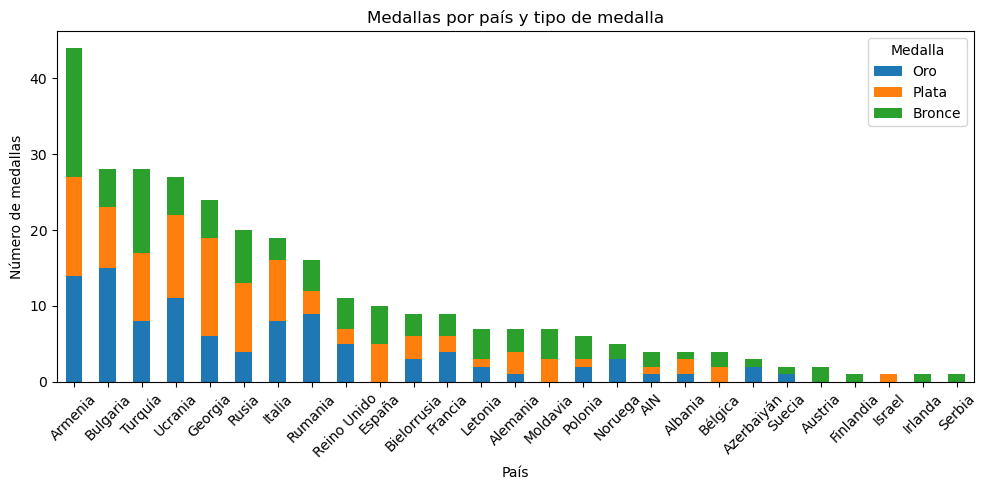

In [ ]:
medallas_pais[["Oro", "Plata", "Bronce"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Medallas por país y tipo de medalla")
plt.xlabel("País")
plt.ylabel("Número de medallas")
plt.legend(title="Medalla")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ¿Qué país ha logrado la mayor equidad en términos de éxito entre sus atletas femeninos y masculinos?

In [ ]:
equidad_f2 = (
    df_ordenado_2
    .groupby(["País", "Género"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Femenino", "Masculino"]:
    if col not in equidad_f2.columns:
        equidad_f2[col] = 0

equidad_f2_validos = equidad_f2[(equidad_f2["Femenino"] > 0) & (equidad_f2["Masculino"] > 0)].copy()

equidad_f2_validos["Diferencia_medallas"] = (equidad_f2_validos["Femenino"] - equidad_f2_validos["Masculino"]).abs()

equidad_f2_validos = equidad_f2_validos.sort_values(["Diferencia_medallas", "Femenino", "Masculino"], ascending=[True, False, False])

display(equidad_f2_validos)


Género,Femenino,Masculino,Diferencia_medallas
País,,,
Alemania,4,3,1
Letonia,3,4,1
Moldavia,3,4,1
Azerbaiyán,1,2,1
España,4,6,2
AIN,1,3,2
Albania,1,3,2
Italia,8,11,3
Turquía,16,12,4


En la Fase 2, varios presentan la menor diferencia posible en el número de medallas entre géneros, concretamente una diferencia de solo 1 medalla.

Estos países son Alemania, Letonia, Azerbaiyán y Moldavia.

El análisis se ha limitado exclusivamente a países con medallas registradas en ambos géneros, asegurando así una comparación justa y metodológicamente sólida.

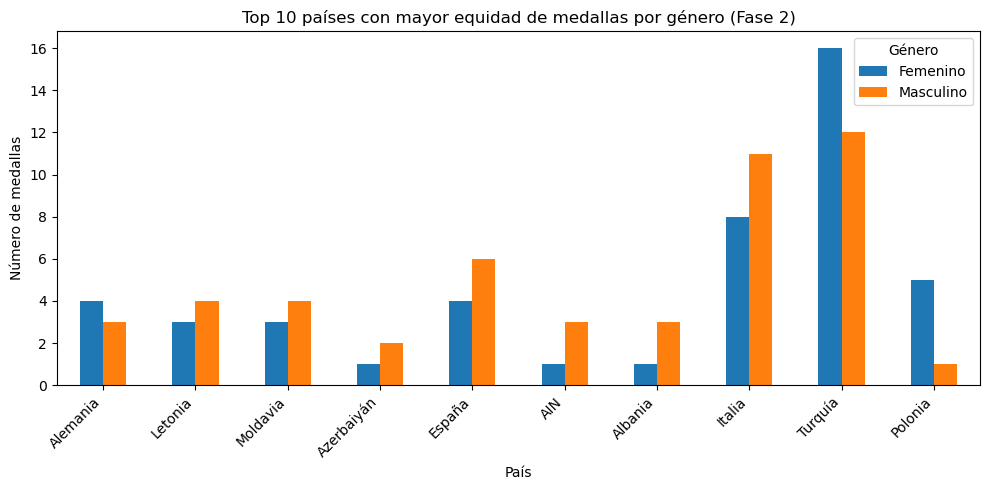

In [ ]:
ax = top10_equidad[["Femenino", "Masculino"]].plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 países con mayor equidad de medallas por género (Fase 2)")
plt.xlabel("País")
plt.ylabel("Número de medallas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### ¿En qué país es menor la diferencia entre el promedio de puntos totales conseguidos por atletas femeninos y masculinos?

In [ ]:
promedio_total_genero_f2 = (
    df_ordenado_2
    .groupby(["País", "Género"])["Total"]
    .mean()
    .unstack()
)

for col in ["Femenino", "Masculino"]:
    if col not in promedio_total_genero_f2.columns:
        promedio_total_genero_f2[col] = pd.NA

promedio_total_genero_f2_validos = promedio_total_genero_f2.dropna(subset=["Femenino", "Masculino"]).copy()

promedio_total_genero_f2_validos["Diferencia"] = (promedio_total_genero_f2_validos["Femenino"] - promedio_total_genero_f2_validos["Masculino"]).abs()

promedio_total_genero_f2_validos = promedio_total_genero_f2_validos.sort_values("Diferencia", ascending=True)

promedio_total_genero_f2_validos_rounded = promedio_total_genero_f2_validos.round(2)

display(promedio_total_genero_f2_validos_rounded.head(20))


Género,Femenino,Masculino,Diferencia
País,,,
Rumania,209.71,246.50,36.79
Ucrania,226.22,321.75,95.53
Alemania,222.75,325.00,102.25
Turquía,198.88,307.67,108.79
Francia,225.00,341.00,116.00
Polonia,206.80,324.00,117.20
Georgia,248.00,365.33,117.33
Letonia,221.67,342.00,120.33
Moldavia,237.67,363.75,126.08


En la Fase 2, Rumanía es el país que muestra la menor diferencia en el promedio de puntos totales entre géneros, manteniendo un nivel de equilibrio muy similar al observado en la Fase 1. 

Este hallazgo evidencia que, incluso al ampliar el periodo de estudio hasta 2024, el rendimiento medio de atletas femeninos y masculinos en Rumanía permanece notablemente equilibrado

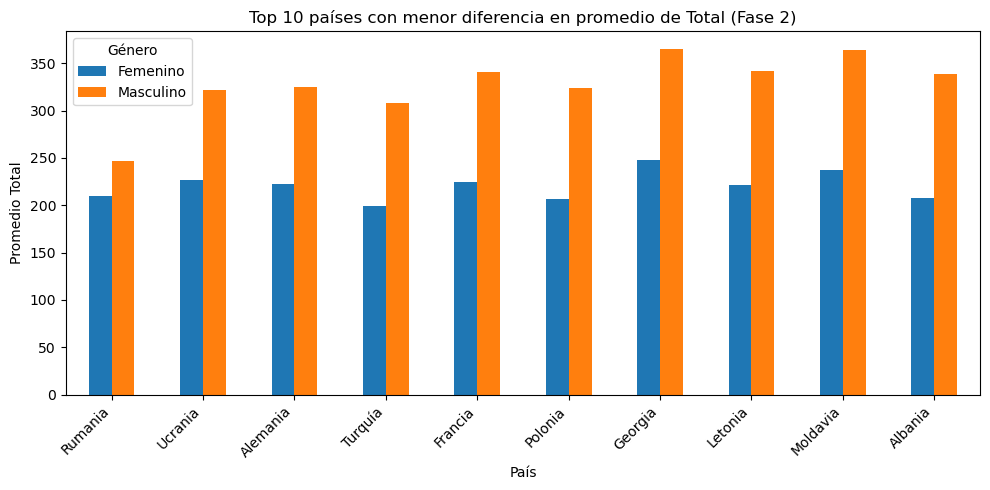

In [ ]:
ax = top10_prom_f2[["Femenino", "Masculino"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 países con menor diferencia en promedio de Total (Fase 2)")
plt.xlabel("País")
plt.ylabel("Promedio Total")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()